# 2. Verifiable settlement

A demand-response payment depends on a counterfactual, the *baseline*: what the campus would have drawn without the event. This notebook reproduces the paper's settlement experiments:

1. the DR contract (S3) fixes ten events at the summer net-load peak and the reduction the campus commits;
2. five baselines estimate the counterfactual, first on honest data, then after the facility inflates its load before each event (+10% over the ten preceding days and in the four hours before the window);
3. the commit–reveal protocol fixes the baseline, its model and its inputs before the season with a SHA-256 hash. The notebook rebuilds the commitment record printed in Appendix D of the paper, byte for byte.

It runs in about two minutes. The physics-guided baseline B5 trains on a single CPU thread, so its weights, and their hash, are the same on every machine.

In [1]:
import os, pathlib, sys
if pathlib.Path.cwd().name == "notebooks":
    os.chdir("..")                      # data paths are relative to experiments/
sys.path.insert(0, ".")

import json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dcflex.config import Site, Facility, System, Tariffs, Study
from dcflex import data, model, analysis
from dcflex.signal import system_signal
from dcflex.style import PALETTE as C, apply_publication_style
%matplotlib inline
apply_publication_style()
plt.rcParams["figure.dpi"] = 110

# the numbers printed in the paper, written by run_all.py and run_ml.py
paper = pd.read_csv("../results/numbers.csv", index_col="macro", dtype=str)["value"]

def check(name, value):
    """Print a value computed here next to the number printed in the paper, at the paper's precision."""
    printed = paper[name]
    decimals = len(printed.split(".")[1]) if "." in printed else 0
    here = f"{value:.{decimals}f}"
    print(f"{name:26s} here {here:>8s}   paper {printed:>8s}   {'same' if here == printed else 'DIFFERENT'}")

In [2]:
site, fac, sysp, tar, st = Site(), Facility(), System(), Tariffs(), Study()
if not pathlib.Path("data/alibaba_jobs.csv").exists():
    raise FileNotFoundError("data/alibaba_jobs.csv is missing: run `python scripts/prep_alibaba_gpu.py` "
                            "from experiments/ once (it downloads the Alibaba GPU trace)")

idx = data.hourly_index(st.year)                                   # 2025, hourly, Gulf time
w = data.fetch_weather(site.lat, site.lon, f"{st.year}-01-01", f"{st.year}-12-31", site.tz,
                       model=st.weather_model)                     # read from data/weather/ (ERA5)
w = w.reindex(idx).interpolate().bfill().ffill()
temp = w["temp"].to_numpy(float)
pv = data.pv_output(w, site.lat, site.lon, fac.pv_mwp, site.tz)    # on-site PV, MW
pv_norm = data.pv_output(w, site.lat, site.lon, 1.0, site.tz)      # per MWp, for the system signal

inf_shape = data.profile_from_csv(idx, "data/azure_llm.csv", "requests")       # interactive inference
def_shape = data.profile_from_csv(idx, "data/alibaba_jobs.csv", "gpu_hours")   # training and batch arrivals
arr, p0 = data.build_arrivals(idx, fac, np.random.default_rng(st.seed + 2), inf_shape, def_shape)
inp = model.inputs(fac, arr, p0, temp, pv)
sig = system_signal(temp, pv_norm, sysp)                           # synthetic 2030 Abu Dhabi net load and price
st.cap_pay_sweep = tuple(sorted(set(st.cap_pay_sweep) | {sysp.cap_value}))   # the base payment is a sweep point
P = analysis.tariff_vectors(idx, tar)
s0 = model.run_monthly(inp, fac, P["addc_commercial"], idx, strategy="bau")
rng = np.random.default_rng(st.seed)
days = analysis.sample_days(idx, st, rng, st.flex_days)    # as in run_all.py: the baseline test draws from the same stream

## The DR contract fixes the events

Under S3 the campus is paid a capacity price for a reduction $r$ that it must deliver in every hour of each event: four hours from the daily net-load peak, on the ten summer days with the highest peaks. At the base payment, the optimal commitment is:

In [3]:
t = time.time()
ev_days, peak_hour, sweep, s3, breakeven = analysis.dr_contract(inp, fac, P["addc_commercial"], idx, sig["net"], st,
                                                                s0["pg"], keep_pay=sysp.cap_value)
r = analysis.base_commitment(sweep, sysp.cap_value)
print(f"payment sweep solved in {time.time() - t:.0f} s")
print("event days:", ", ".join(pd.Timestamp(idx[d * 24]).strftime("%d %b") for d in ev_days))
check("RdrFirmMW", r)

payment sweep solved in 16 s
event days: 01 Aug, 05 Aug, 06 Aug, 09 Aug, 15 Aug, 16 Aug, 17 Aug, 26 Aug, 27 Aug, 04 Sep
RdrFirmMW                  here     35.2   paper     35.2   same


## Five baselines, honest and inflated

- **B1 High-5-of-10**: the mean of the five highest of the last ten working days, with a day-of adjustment (a common utility baseline).
- **B2 Rolling regression**: a time-of-week-and-temperature (TOWT) regression refitted on the 30 days before each event.
- **B3 Committed regression**: the same regression, fitted once on the 60 days before the season and committed.
- **B4 Digital twin**: a physics model of the facility, with a deliberately imperfect chiller curve.
- **B5 Physics-guided network**: a neural baseline whose response to temperature is monotone and convex by construction, trained on the 60 pre-season days and committed.

Accuracy is measured on placebo windows (non-event summer days, where the true counterfactual is known). Over-crediting is the credited reduction in excess of the true reduction when the facility inflates its load, as a share of the true reduction.

In [4]:
import dataclasses
from dcflex import baselines, learned_batch, protocol

ft = dataclasses.replace(fac, cop_slope=fac.cop_slope * 1.15)           # B4: the twin's chiller is 15% off
k = np.ones(3) / 3
arr_s = {c: np.convolve(arr[c], k, mode="same") for c in ("trn", "bat")}
twin = model.bau(model.inputs(ft, arr_s, p0, temp, pv), ft)["pg"]
dew = data.dew_point(temp, w["rh"].to_numpy(float))
b5 = learned_batch.committed(idx.hour.to_numpy(), idx.dayofweek.to_numpy(), temp, dew, pv,
                             baselines.pre_season(idx, st), epochs=1500)

t = time.time()
acc, shop = baselines.experiment(s0["pg"], temp, twin, idx, ev_days, peak_hour, st, r, rng, learned=b5)
print(f"baseline experiment in {time.time() - t:.0f} s (includes training B5)")
pd.DataFrame(acc).T.rename(index=baselines.NAMES, columns={"bias": "Bias (%)", "nmae": "nMAE (%)",
                                                           "cvrmse": "CV(RMSE) (%)", "overcredit": "Over-crediting (%)"}).round(1)

baseline experiment in 10 s (includes training B5)


,Bias (%),nMAE (%),CV(RMSE) (%),Over-crediting (%)
High-5-of-10,10.4,14.8,18.7,57.3
Rolling regression,0.2,2.6,3.9,29.1
Committed regression,0.5,2.9,4.8,3.4
Digital twin,0.1,2.9,3.9,1.7
Physics-guided network,0.1,3.0,4.8,1.2


In [5]:
check("RgamingOverpayHighPct", acc["b1"]["overcredit"])
check("RgamingOverpayRollPct", acc["b2"]["overcredit"])
check("RgamingOverpayCommitPct", acc["b3"]["overcredit"])
check("RgamingOverpayLearnedPct", acc["b5"]["overcredit"])
check("RshoppingOverpayPct", shop)      # choosing the most generous baseline after the event

RgamingOverpayHighPct      here     57.3   paper     57.3   same
RgamingOverpayRollPct      here     29.1   paper     29.1   same
RgamingOverpayCommitPct    here      3.4   paper      3.4   same
RgamingOverpayLearnedPct   here      1.2   paper      1.2   same
RshoppingOverpayPct        here     34.4   paper     34.4   same


One event in detail (the one with the highest net-load peak). Inflating the load before the event raises the rolling baselines, B1 and B2, and so the credited reduction. The committed baselines were fixed before the inflation began, so their credit does not move.

RinflCreditHighMW          here     50.5   paper     50.5   same
RinflCreditCommitMW        here     33.9   paper     33.9   same


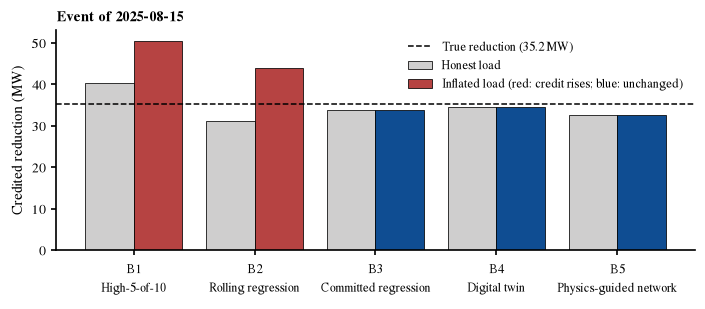

In [6]:
ex = baselines.inflation_example(s0["pg"], temp, twin, idx, ev_days, peak_hour, st, r, sig["net"],
                                 learned_pred=b5(s0["pg"]))
names = [f"B{i + 1}" for i in range(len(baselines.NAMES))]
honest = [np.mean(ex["clean"][b] - ex["metered"]) for b in baselines.NAMES]
inflated = [np.mean(ex["gamed"][b] - ex["metered"]) for b in baselines.NAMES]

fig, ax = plt.subplots(figsize=(6.5, 2.9))
x = np.arange(len(names))
ax.bar(x - 0.2, honest, 0.4, color=C["neutral"], edgecolor="black", lw=0.5, label="Honest load")
ax.bar(x + 0.2, inflated, 0.4, color=[C["red_strong"] if g > h + 0.5 else C["blue_main"] for g, h in zip(inflated, honest)],
       edgecolor="black", lw=0.5, label="Inflated load (red: credit rises; blue: unchanged)")
ax.axhline(ex["r_true"], color="black", ls="--", lw=1, label=f"True reduction ({ex['r_true']:.1f} MW)")
ax.set_xticks(x, [f"{n}\n{baselines.NAMES[b]}" for n, b in zip(names, baselines.NAMES)], fontsize=8)
ax.set(ylabel="Credited reduction (MW)", title=f"Event of {ex['date']}")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
check("RinflCreditHighMW", inflated[0])
check("RinflCreditCommitMW", inflated[2])

## Commit before the season, reveal after the event

On the eve of each event, the operator publishes one hash, $C = \mathrm{SHA\text{-}256}(\text{record})$. The record holds the event, the commitment time, the event window, the baseline in MW, the SHA-256 hashes of the baseline model (here the committed regression's coefficients, fixed since the start of the season) and of its inputs (the event window's temperatures), and a random nonce. After the event the operator reveals the record; anyone can recompute the hashes and check that nothing changed.

In operation the inputs would be the day-ahead temperature forecast; as in Appendix D, the example uses the observed temperatures. The nonce is seeded here so that the record matches Appendix D; in operation it is drawn from a secure random source.

In [7]:
model_bytes = np.asarray(ex["coef"], float).tobytes()
feature_bytes = np.asarray(ex["features"], float).tobytes()
eve = (pd.Timestamp(ex["date"]) - pd.Timedelta(days=1)).strftime("%Y-%m-%dT12:00:00+04:00")   # noon on the eve of the event
C_hash, rec = protocol.commit(f"AD-DR-{ex['date']}", eve,
                              [ex["event_day"] * 24 + h for h in ex["hrs"]], ex["clean"]["b3"],
                              model_bytes, feature_bytes, nonce=np.random.default_rng(st.seed + 7).bytes(32).hex())
print(json.dumps(rec, indent=1))
print("C =", C_hash)

published = open("../results/commit-example.txt").read()
print("\nsame record and hash as Appendix D:", json.dumps(rec, indent=1) in published and C_hash in published)

{
 "event_id": "AD-DR-2025-08-15",
 "t_commit": "2025-08-14T12:00:00+04:00",
 "window": [
  5443,
  5444,
  5445,
  5446
 ],
 "baseline_mw": [
  90.3093,
  94.885,
  88.6974,
  109.0011
 ],
 "model_sha256": "9f6f21ac120f4297ab0a8f78300e69560e10b299b5808bd6e5d5ee480f74d95e",
 "features_sha256": "4b0917f7a03a49c637391c1fea86655f8c336dadf2adb88ed3147bbf8d45afd9",
 "nonce": "3d4e7826a252bbd4414941a73100675ce879b3161fb9e6b3fdbb1c59abbe30dc"
}
C = 716aaf3829695ff8e52445622237d9f6d2a0b060a0218655df1619c7ef4a1c67

same record and hash as Appendix D: True


In [8]:
print("revealed record verifies:          ", protocol.verify(C_hash, rec, model_bytes, feature_bytes))

tampered = dict(rec, baseline_mw=[rec["baseline_mw"][0] + 0.1] + rec["baseline_mw"][1:])
print("baseline raised by 0.1 MW verifies:", protocol.verify(C_hash, tampered, model_bytes, feature_bytes))

other_model = (np.asarray(ex["coef"], float) * 1.001).tobytes()
print("a different model verifies:        ", protocol.verify(C_hash, rec, other_model, feature_bytes))

micros, nbytes = protocol.benchmark()
print(f"\ncommit and verify: {micros:.1f} µs on this machine; {nbytes:.0f} bytes per record")

revealed record verifies:           True
baseline raised by 0.1 MW verifies: False
a different model verifies:         False



commit and verify: 39.8 µs on this machine; 371 bytes per record


B5 is committed the same way: its weights are serialized deterministically and hashed before the season.

In [9]:
import hashlib
weights = learned_batch.model_bytes(b5.info["net"])
print(f"{sum(q.numel() for q in b5.info['net'].parameters())} parameters, {len(weights) / 1024:.0f} kB")
digest = hashlib.sha256(weights).hexdigest()[:16]
print(f"RbfiveDigest               here {digest}   paper {paper['RbfiveDigest']}   {'same' if digest == paper['RbfiveDigest'] else 'DIFFERENT'}")

10895 parameters, 85 kB
RbfiveDigest               here 1ac8570332c648a4   paper 1ac8570332c648a4   same
